# Notebook 04: Temperature Scaling and Internal Test Evaluation — Main19

This notebook:

1. Loads the best EfficientNet-B0 checkpoint from Notebook 03.
2. Fits a single temperature parameter on the Main19 calibration set
   (19-class selected subset, 3,197 images).
3. Evaluates both uncalibrated and temperature-scaled predictions on the
   locked internal-test manifest (5,322 images), which was not used for
   training, early stopping, or calibration fitting.

This is the *first and only* use of the internal-test manifest.

In [1]:
import os
import gc
import json
from pathlib import Path
from datetime import datetime, timezone
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    brier_score_loss,
    log_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 7

os.environ["PYTHONHASHSEED"] = str(SEED)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU capability:", torch.cuda.get_device_capability(0))

if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)
    print("GPU:", gpu_name)
    print("CUDA capability:", capability)
    assert capability >= (7, 0), (
        f"{gpu_name} has capability {capability}, but this PyTorch build "
        "requires 7.0 or newer. Select a T4 GPU."
    )

Device: cuda
PyTorch version: 2.10.0+cu128
CUDA version: 12.8
CUDA available: True
GPU: Tesla T4
GPU capability: (7, 5)
GPU: Tesla T4
CUDA capability: (7, 5)


In [2]:
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

OUTPUT_DIR = WORK_DIR / "main19_test_evaluation_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, METADATA_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Input root:", INPUT_ROOT)
print("Output directory:", OUTPUT_DIR)

Input root: /kaggle/input
Output directory: /kaggle/working/main19_test_evaluation_outputs


In [3]:
def find_input_file(keyword):
    matches = list(INPUT_ROOT.rglob(keyword))
    if not matches:
        raise FileNotFoundError(
            f"Could not find any file matching '{keyword}' under /kaggle/input. "
            "Attach the required datasets from Notebook 02 and Notebook 03."
        )
    if len(matches) > 1:
        print(f"Multiple matches for {keyword}:")
        for match in matches:
            print(" -", match)
        print("Using:", matches[0])
    return matches[0]


TRAIN_MANIFEST_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv"
CALIBRATION_MANIFEST_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv"
TEST_MANIFEST_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_internal_test.csv"
CLASS_MAPPING_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json"
PROTOCOL_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/data_protocol.json"

BEST_CHECKPOINT_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/best_efficientnet_b0_main19.pt"
CALIBRATION_PREDICTIONS_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/calibration_predictions_best_model.csv"
TRAINING_CONFIG_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/training_config.json"

print("\nTrain manifest:      ", TRAIN_MANIFEST_PATH)
print("Calibration manifest:", CALIBRATION_MANIFEST_PATH)
print("Internal-test manifest:", TEST_MANIFEST_PATH)
print("Class mapping:       ", CLASS_MAPPING_PATH)
print("Data protocol:       ", PROTOCOL_PATH)
print("Best checkpoint:     ", BEST_CHECKPOINT_PATH)
print("Calibration preds:   ", CALIBRATION_PREDICTIONS_PATH)
print("Training config:     ", TRAINING_CONFIG_PATH)


Train manifest:       /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv
Calibration manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv
Internal-test manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_internal_test.csv
Class mapping:        /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json
Data protocol:        /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/data_protocol.json
Best checkpoint:      /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/best_efficientnet_b0_main19.pt
Calibration preds:    /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/calibration_predictions_best_model.csv
Training 

In [4]:
train_df = pd.read_csv(TRAIN_MANIFEST_PATH)
calibration_df = pd.read_csv(CALIBRATION_MANIFEST_PATH)
test_df = pd.read_csv(TEST_MANIFEST_PATH)

with open(CLASS_MAPPING_PATH, "r") as file:
    class_to_index = json.load(file)

index_to_class = {int(idx): label for label, idx in class_to_index.items()}
NUM_CLASSES = len(class_to_index)

with open(PROTOCOL_PATH, "r") as file:
    data_protocol = json.load(file)

required_columns = {"image_path", "label", "final_split"}

for name, df in [
    ("train", train_df),
    ("calibration", calibration_df),
    ("test", test_df),
]:
    missing = required_columns - set(df.columns)
    assert not missing, f"{name} manifest missing columns: {missing}"

assert set(train_df["final_split"]) == {"train"}
assert set(calibration_df["final_split"]) == {"calibration"}
assert set(test_df["final_split"]) == {"internal_test"}

assert train_df["label"].nunique() == NUM_CLASSES
assert calibration_df["label"].nunique() == NUM_CLASSES
assert test_df["label"].nunique() == NUM_CLASSES

assert set(train_df["label"]) == set(class_to_index)
assert set(calibration_df["label"]) == set(class_to_index)
assert set(test_df["label"]) == set(class_to_index)

assert set(train_df["image_path"]).isdisjoint(set(calibration_df["image_path"]))
assert set(train_df["image_path"]).isdisjoint(set(test_df["image_path"]))
assert set(calibration_df["image_path"]).isdisjoint(set(test_df["image_path"]))

print("Train images:      ", len(train_df))
print("Calibration images:", len(calibration_df))
print("Internal-test images:", len(test_df))
print("Classes:", NUM_CLASSES)

print("\nPASS: All manifests consistent and splits are disjoint.")

Train images:       18113
Calibration images: 3197
Internal-test images: 5322
Classes: 19

PASS: All manifests consistent and splits are disjoint.


In [5]:
test_exists = test_df["image_path"].map(lambda path: Path(path).exists())
print("Existing test image paths:", int(test_exists.sum()), "/", len(test_df))

assert test_exists.all(), (
    f"{int((~test_exists).sum())} internal-test image paths do not exist."
)

print("PASS: All internal-test image files exist.")

Existing test image paths: 5322 / 5322
PASS: All internal-test image files exist.


In [6]:
IMAGE_SIZE = 224

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, class_to_index, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.class_to_index = class_to_index
        self.transform = transform

        self.image_paths = self.dataframe["image_path"].tolist()
        self.labels = self.dataframe["label"].tolist()
        self.targets = [self.class_to_index[label] for label in self.labels]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        target = self.targets[index]

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
        except Exception as error:
            raise RuntimeError(
                f"Could not load image at index {index}: {image_path}"
            ) from error

        image = self.transform(image)

        return {
            "image": image,
            "target": torch.tensor(target, dtype=torch.long),
            "path": image_path
        }

test_dataset = PlantDiseaseDataset(
    dataframe=test_df,
    class_to_index=class_to_index,
    transform=EVAL_TRANSFORM
)

print("Test dataset size:", len(test_dataset))

Test dataset size: 5322


In [7]:
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == "cuda"

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print("Test batches:", len(test_loader))

Test batches: 167


In [8]:
with open(TRAINING_CONFIG_PATH, "r") as file:
    training_config = json.load(file)

print(json.dumps(training_config, indent=2))

weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
model = models.efficientnet_b0(weights=weights)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, NUM_CLASSES)
)

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("\nLoaded checkpoint from:")
print(BEST_CHECKPOINT_PATH)
print("Best calibration macro-F1:", checkpoint["best_calibration_macro_f1"])
print("Epoch:", checkpoint["epoch"])

{
  "architecture": "EfficientNet-B0",
  "pretrained_weights": "IMAGENET1K_V1",
  "num_classes": 19,
  "image_size": 224,
  "batch_size": 32,
  "epochs_maximum": 15,
  "learning_rate": 0.0003,
  "weight_decay": 0.0001,
  "early_stopping_patience": 4,
  "loss": "class-weighted cross-entropy",
  "selection_metric": "calibration macro-F1",
  "seed": 7,
  "device": "cuda"
}
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 216MB/s]



Loaded checkpoint from:
/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/nb0_3/nb0_3/best_efficientnet_b0_main19.pt
Best calibration macro-F1: 0.9939520934929097
Epoch: 15


In [9]:
@torch.no_grad()
def collect_logits_and_targets(model, loader, device):
    model.eval()

    all_logits = []
    all_targets = []
    all_paths = []

    progress_bar = tqdm(loader, desc="Collecting logits", leave=False)

    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda"
        ):
            logits = model(images)

        all_logits.append(logits.cpu())
        all_targets.append(targets.cpu())
        all_paths.extend(batch["path"])

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    return all_logits, all_targets, all_paths

In [10]:
calibration_dataset_eval = PlantDiseaseDataset(
    dataframe=calibration_df,
    class_to_index=class_to_index,
    transform=EVAL_TRANSFORM
)

calibration_loader_eval = DataLoader(
    calibration_dataset_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

calib_logits, calib_targets, calib_paths = collect_logits_and_targets(
    model=model,
    loader=calibration_loader_eval,
    device=DEVICE
)

print("Calibration logits shape:", calib_logits.shape)
print("Calibration targets shape:", calib_targets.shape)

Calibration logits shape: torch.Size([3197, 19])
Calibration targets shape: torch.Size([3197])


In [11]:
class TemperatureScaler(nn.Module):
    def __init__(self, init_temperature=1.0):
        super().__init__()
        self.log_temperature = nn.Parameter(
            torch.log(torch.tensor(float(init_temperature)))
        )

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def forward(self, logits):
        temp = self.temperature.unsqueeze(0)
        return logits / temp

In [12]:
def nll_criterion(logits, targets):
    log_probs = torch.log_softmax(logits, dim=1)
    return nn.NLLLoss()(log_probs, targets)


temperature_scaler = TemperatureScaler(init_temperature=1.0).to(DEVICE)

optimizer_t = torch.optim.LBFGS(
    [temperature_scaler.log_temperature],
    lr=0.01,
    max_iter=50
)

calib_logits_device = calib_logits.to(DEVICE)
calib_targets_device = calib_targets.to(DEVICE)

print("Initial temperature:", float(temperature_scaler.temperature))


def _closure():
    optimizer_t.zero_grad(set_to_none=True)
    scaled_logits = temperature_scaler(calib_logits_device)
    loss = nll_criterion(scaled_logits, calib_targets_device)
    loss.backward()
    return loss


for step in range(20):
    loss = optimizer_t.step(_closure)
    with torch.no_grad():
        temp_value = float(temperature_scaler.temperature)
    print(f"Step {step+1:02d} | NLL: {loss.item():.6f} | T: {temp_value:.4f}")

print("\nFitted temperature:", float(temperature_scaler.temperature))

Initial temperature: 1.0


/tmp/ipykernel_58/1387475177.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Initial temperature:", float(temperature_scaler.temperature))


Step 01 | NLL: 0.023648 | T: 1.2753
Step 02 | NLL: 0.019722 | T: 1.4137
Step 03 | NLL: 0.018712 | T: 1.4825
Step 04 | NLL: 0.018433 | T: 1.5197
Step 05 | NLL: 0.018345 | T: 1.5408
Step 06 | NLL: 0.018316 | T: 1.5532
Step 07 | NLL: 0.018305 | T: 1.5605
Step 08 | NLL: 0.018302 | T: 1.5648
Step 09 | NLL: 0.018300 | T: 1.5675
Step 10 | NLL: 0.018300 | T: 1.5688
Step 11 | NLL: 0.018300 | T: 1.5689
Step 12 | NLL: 0.018300 | T: 1.5689
Step 13 | NLL: 0.018300 | T: 1.5690
Step 14 | NLL: 0.018300 | T: 1.5691
Step 15 | NLL: 0.018300 | T: 1.5693
Step 16 | NLL: 0.018300 | T: 1.5693
Step 17 | NLL: 0.018300 | T: 1.5694
Step 18 | NLL: 0.018300 | T: 1.5694
Step 19 | NLL: 0.018300 | T: 1.5694
Step 20 | NLL: 0.018300 | T: 1.5695

Fitted temperature: 1.5694622993469238


In [13]:
def compute_ece(probs, targets, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)

    accuracies = (predictions == targets).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        start = bin_edges[i]
        end = bin_edges[i + 1]

        in_bin = (confidences > start) & (confidences <= end)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += prop_in_bin * abs(avg_confidence_in_bin - accuracy_in_bin)

    return ece


def metrics_from_logits(logits_tensor, targets_tensor, split_name):
    logits = logits_tensor.cpu().numpy()
    targets = targets_tensor.cpu().numpy()

    probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)

    acc = accuracy_score(targets, preds)
    bal_acc = balanced_accuracy_score(targets, preds)
    macro_f1 = f1_score(targets, preds, average="macro", zero_division=0)

    nll = log_loss(targets, probs, labels=list(range(NUM_CLASSES)))
    one_hot_targets = np.eye(NUM_CLASSES, dtype=np.float64)[targets]

        # Standard multiclass Brier score:
        # mean over images of the sum of squared class-probability errors.
    brier = np.mean(
    np.sum((probs - one_hot_targets) ** 2, axis=1)
    )
    ece = compute_ece(probs, targets, n_bins=15)

    return {
        "split": split_name,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "nll": nll,
        "brier": brier,
        "ece": ece
    }, probs, preds


# Uncalibrated calibration metrics
calib_uncal_metrics, calib_uncal_probs, calib_uncal_preds = metrics_from_logits(
    calib_logits,
    calib_targets,
    split_name="calibration_uncalibrated"
)

# Temperature-scaled calibration metrics
with torch.no_grad():
    scaled_calib_logits = temperature_scaler(calib_logits.to(DEVICE)).cpu()

calib_cal_metrics, calib_cal_probs, calib_cal_preds = metrics_from_logits(
    scaled_calib_logits,
    calib_targets,
    split_name="calibration_temperature_scaled"
)

pd.DataFrame([calib_uncal_metrics, calib_cal_metrics])

,split,accuracy,balanced_accuracy,macro_f1,nll,brier,ece
0,calibration_uncalibrated,0.995934,0.993856,0.993952,0.0185,0.006992,0.003923
1,calibration_temperature_scaled,0.995934,0.993856,0.993952,0.0183,0.006775,0.001297


In [14]:
test_logits, test_targets, test_paths = collect_logits_and_targets(
    model=model,
    loader=test_loader,
    device=DEVICE
)

print("Test logits shape:", test_logits.shape)
print("Test targets shape:", test_targets.shape)
print("Test images:", len(test_paths))

Test logits shape: torch.Size([5322, 19])
Test targets shape: torch.Size([5322])
Test images: 5322


In [15]:
# Uncalibrated
test_uncal_metrics, test_uncal_probs, test_uncal_preds = metrics_from_logits(
    test_logits,
    test_targets,
    split_name="test_uncalibrated"
)

# Temperature scaled
with torch.no_grad():
    scaled_test_logits = temperature_scaler(test_logits.to(DEVICE)).cpu()

test_cal_metrics, test_cal_probs, test_cal_preds = metrics_from_logits(
    scaled_test_logits,
    test_targets,
    split_name="test_temperature_scaled"
)

metrics_df = pd.DataFrame([
    calib_uncal_metrics,
    calib_cal_metrics,
    test_uncal_metrics,
    test_cal_metrics
])

metrics_path = TABLE_DIR / "main19_temperature_scaling_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)

,split,accuracy,balanced_accuracy,macro_f1,nll,brier,ece
0,calibration_uncalibrated,0.995934,0.993856,0.993952,0.018500,0.006992,0.003923
1,calibration_temperature_scaled,0.995934,0.993856,0.993952,0.018300,0.006775,0.001297
2,test_uncalibrated,0.995303,0.993204,0.992931,0.015501,0.007042,0.003206
3,test_temperature_scaled,0.995303,0.993204,0.992931,0.015925,0.006416,0.002279


Saved: /kaggle/working/main19_test_evaluation_outputs/tables/main19_temperature_scaling_metrics.csv


In [16]:
class_names = [index_to_class[i] for i in range(NUM_CLASSES)]

# Uncalibrated
report_uncal = classification_report(
    test_targets,
    test_uncal_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_uncal_df = (
    pd.DataFrame(report_uncal)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

uncal_report_path = TABLE_DIR / "test_classification_report_uncalibrated.csv"
report_uncal_df.to_csv(uncal_report_path, index=False)

# Temperature scaled — classification metrics are same labels,
# but probabilities are calibrated. Predicted class argmax is identical
# unless there are exact ties, so macro-F1 etc. should differ minimally.
report_cal = classification_report(
    test_targets,
    test_cal_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_cal_df = (
    pd.DataFrame(report_cal)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

cal_report_path = TABLE_DIR / "test_classification_report_temperature_scaled.csv"
report_cal_df.to_csv(cal_report_path, index=False)

display(report_uncal_df.head())
display(report_cal_df.head())

print("Saved:")
print("  ", uncal_report_path)
print("  ", cal_report_path)

,class_or_average,precision,recall,f1-score,support
0,bell_pepper__bacterial_spot,1.000000,1.000000,1.000000,200.0
1,bell_pepper__healthy,0.996622,1.000000,0.998308,295.0
2,corn__cercospora_leaf_spot_gray_leaf_spot,0.924528,0.951456,0.937799,103.0
3,corn__common_rust,1.000000,0.995816,0.997904,239.0
4,corn__healthy,1.000000,1.000000,1.000000,232.0


,class_or_average,precision,recall,f1-score,support
0,bell_pepper__bacterial_spot,1.000000,1.000000,1.000000,200.0
1,bell_pepper__healthy,0.996622,1.000000,0.998308,295.0
2,corn__cercospora_leaf_spot_gray_leaf_spot,0.924528,0.951456,0.937799,103.0
3,corn__common_rust,1.000000,0.995816,0.997904,239.0
4,corn__healthy,1.000000,1.000000,1.000000,232.0


Saved:
   /kaggle/working/main19_test_evaluation_outputs/tables/test_classification_report_uncalibrated.csv
   /kaggle/working/main19_test_evaluation_outputs/tables/test_classification_report_temperature_scaled.csv


In [17]:
test_predictions_df = test_df[["image_path", "label"]].copy()

test_predictions_df["true_class_index"] = test_targets.numpy()
test_predictions_df["predicted_class_index_uncal"] = test_uncal_preds
test_predictions_df["predicted_class_index_cal"] = test_cal_preds

test_predictions_df["predicted_label_uncal"] = [
    index_to_class[idx] for idx in test_uncal_preds
]

test_predictions_df["predicted_label_cal"] = [
    index_to_class[idx] for idx in test_cal_preds
]

test_predictions_df["confidence_uncal"] = test_uncal_probs.max(axis=1)
test_predictions_df["confidence_cal"] = test_cal_probs.max(axis=1)

for class_index, class_name in index_to_class.items():
    test_predictions_df[
        f"prob_uncal_{class_index:02d}_{class_name}"
    ] = test_uncal_probs[:, class_index]

    test_predictions_df[
        f"prob_cal_{class_index:02d}_{class_name}"
    ] = test_cal_probs[:, class_index]

test_predictions_path = TABLE_DIR / "test_predictions_uncalibrated_and_calibrated.csv"
test_predictions_df.to_csv(test_predictions_path, index=False)

display(test_predictions_df.head())
print("Saved:", test_predictions_path)

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,image_path,label,true_class_index,predicted_class_index_uncal,predicted_class_index_cal,predicted_label_uncal,predicted_label_cal,confidence_uncal,confidence_cal,prob_uncal_00_bell_pepper__bacterial_spot,...,prob_uncal_14_tomato__septoria_leaf_spot,prob_cal_14_tomato__septoria_leaf_spot,prob_uncal_15_tomato__spider_mites_two_spotted_spider_mite,prob_cal_15_tomato__spider_mites_two_spotted_spider_mite,prob_uncal_16_tomato__target_spot,prob_cal_16_tomato__target_spot,prob_uncal_17_tomato__tomato_mosaic_virus,prob_cal_17_tomato__tomato_mosaic_virus,prob_uncal_18_tomato__tomato_yellow_leaf_curl_virus,prob_cal_18_tomato__tomato_yellow_leaf_curl_virus
0,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__cercospora_leaf_spot_gray_leaf_spot,2,2,2,corn__cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,1.000000,0.999978,0.0,...,0.0,3.230104e-08,0.0,9.372377e-08,0.000000e+00,4.942021e-07,0.0,9.927977e-09,0.000000e+00,8.400190e-08
1,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__cercospora_leaf_spot_gray_leaf_spot,2,2,2,corn__cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,1.000000,0.999892,0.0,...,0.0,7.358922e-07,0.0,1.310954e-06,0.000000e+00,1.492091e-06,0.0,1.172453e-07,0.000000e+00,7.249850e-07
2,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__cercospora_leaf_spot_gray_leaf_spot,2,2,2,corn__cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,1.000000,0.999577,0.0,...,0.0,3.764963e-06,0.0,5.648726e-06,0.000000e+00,1.177123e-05,0.0,1.465859e-06,0.000000e+00,5.620681e-06
3,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__cercospora_leaf_spot_gray_leaf_spot,2,2,2,corn__cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,0.972656,0.906792,0.0,...,0.0,2.676222e-06,0.0,1.078542e-05,5.960464e-08,1.814469e-05,0.0,3.764935e-07,5.960464e-08,1.570565e-05
4,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__cercospora_leaf_spot_gray_leaf_spot,2,2,2,corn__cercospora_leaf_spot_gray_leaf_spot,corn__cercospora_leaf_spot_gray_leaf_spot,1.000000,0.999965,0.0,...,0.0,2.325569e-08,0.0,2.461734e-07,0.000000e+00,1.222795e-06,0.0,4.858267e-08,0.000000e+00,2.365628e-07


Saved: /kaggle/working/main19_test_evaluation_outputs/tables/test_predictions_uncalibrated_and_calibrated.csv


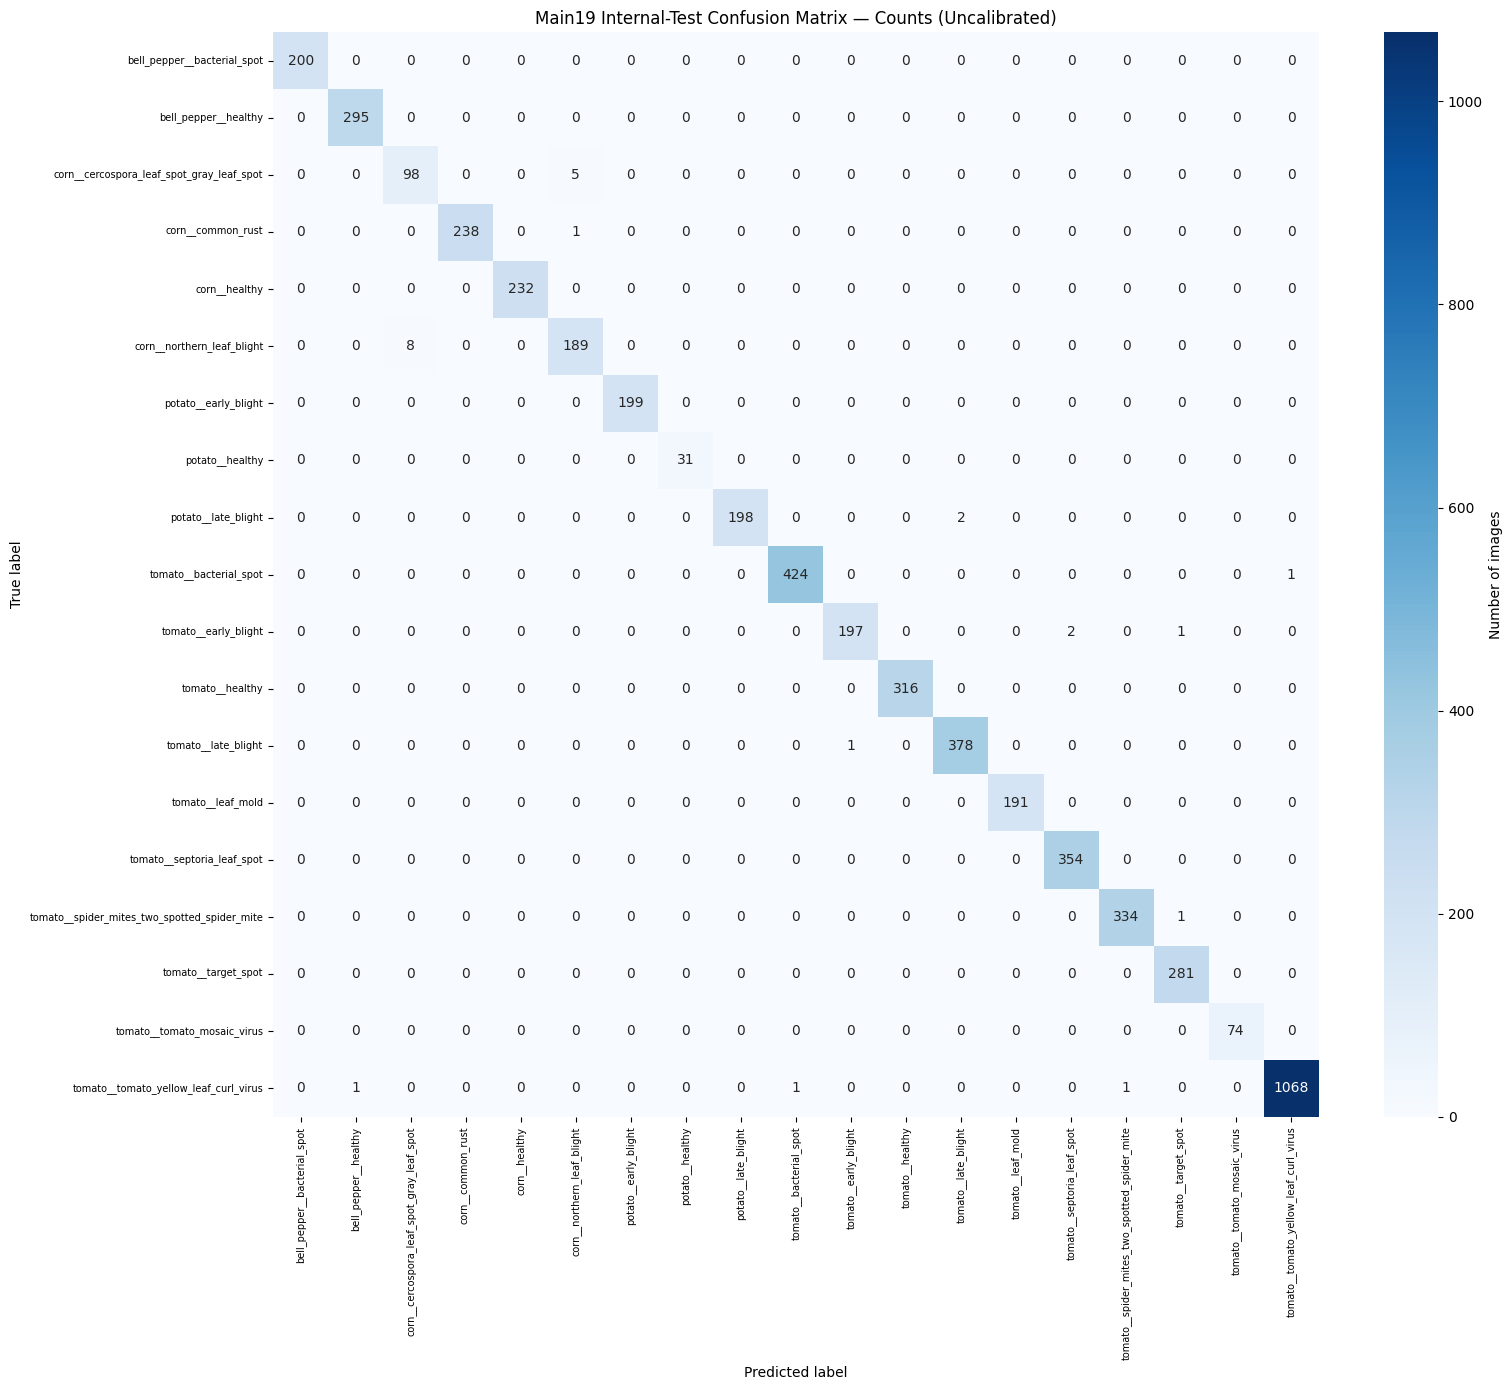

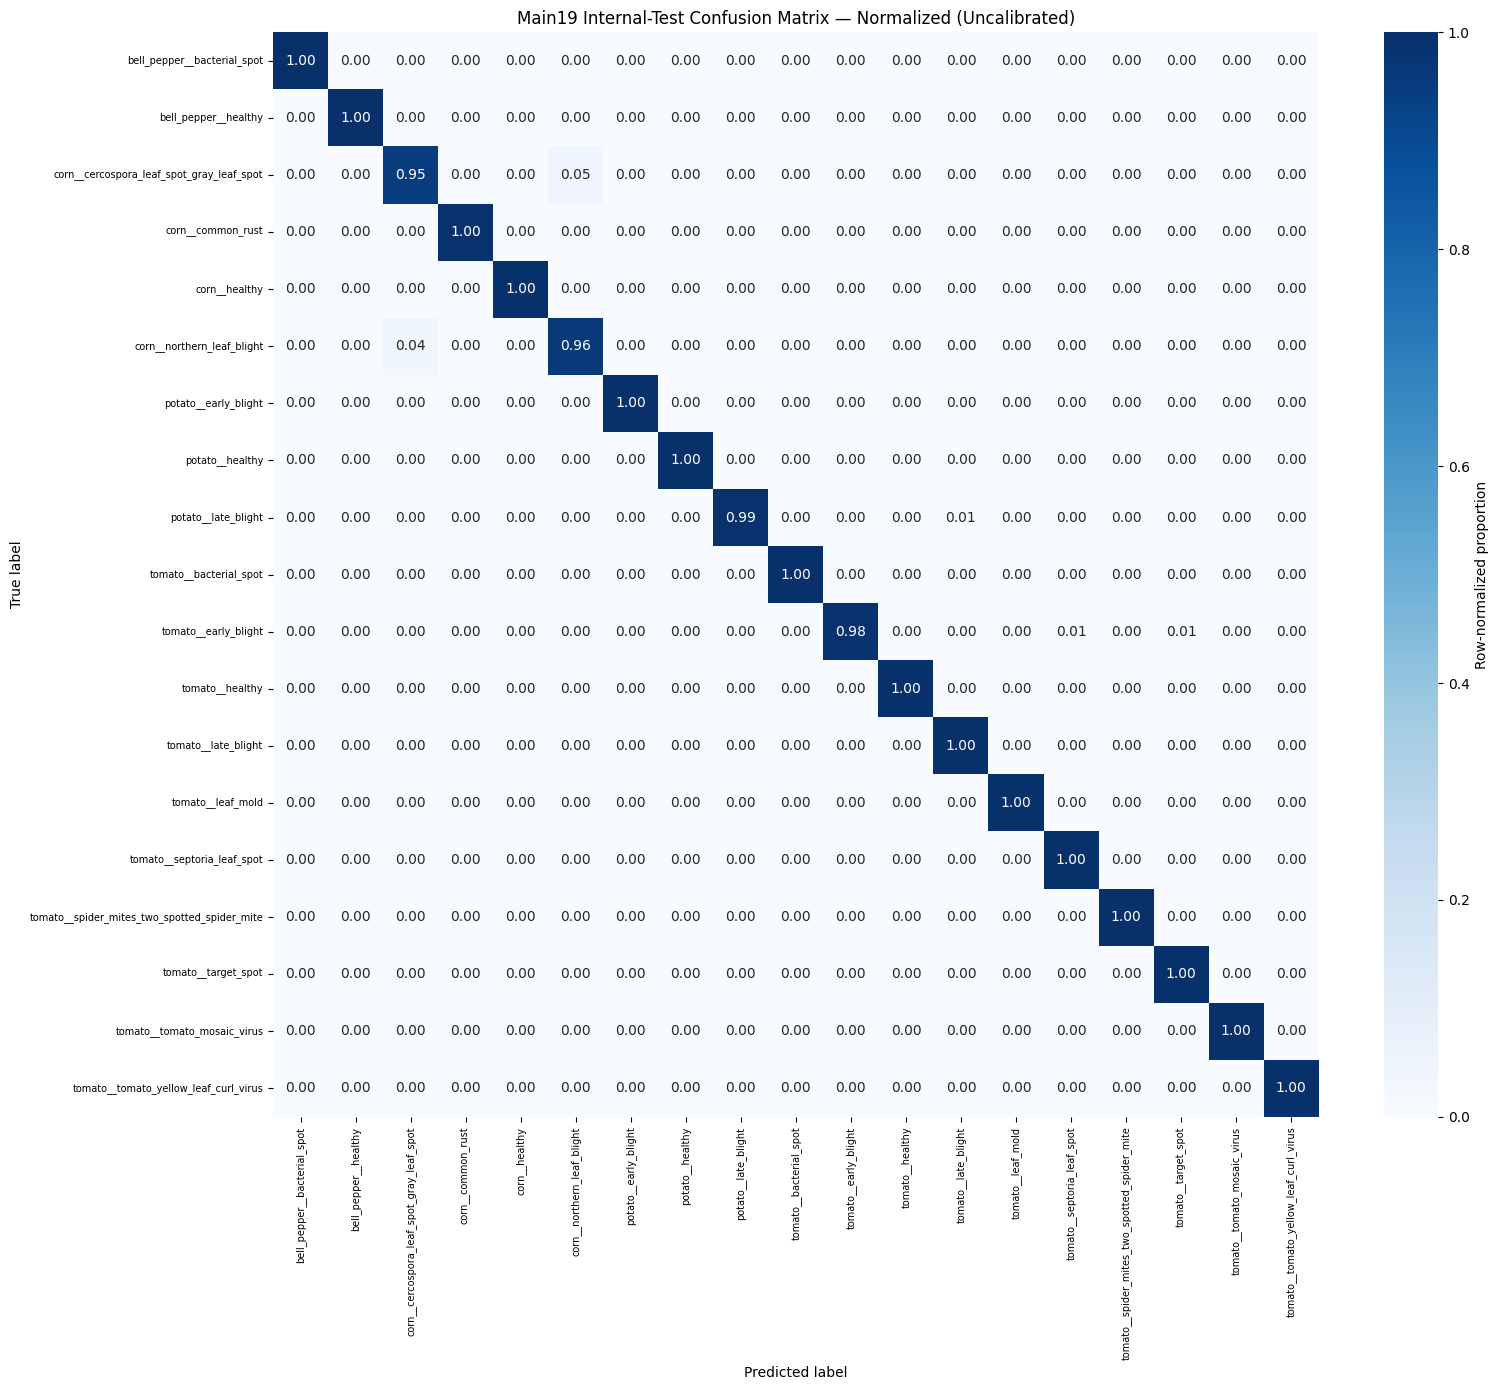

Saved:
  /kaggle/working/main19_test_evaluation_outputs/figures/fig_01_test_confusion_matrix_counts_uncalibrated.png
  /kaggle/working/main19_test_evaluation_outputs/figures/fig_02_test_confusion_matrix_normalized_uncalibrated.png


In [18]:
cm_counts = confusion_matrix(
    test_targets,
    test_uncal_preds,
    labels=list(range(NUM_CLASSES)),
    normalize=None
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_counts,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d",
    cbar_kws={"label": "Number of images"}
)

plt.title("Main19 Internal-Test Confusion Matrix — Counts (Uncalibrated)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

cm_counts_path = FIG_DIR / "fig_01_test_confusion_matrix_counts_uncalibrated.png"
plt.savefig(cm_counts_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

cm_norm = confusion_matrix(
    test_targets,
    test_uncal_preds,
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Row-normalized proportion"}
)

plt.title("Main19 Internal-Test Confusion Matrix — Normalized (Uncalibrated)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

cm_norm_path = FIG_DIR / "fig_02_test_confusion_matrix_normalized_uncalibrated.png"
plt.savefig(cm_norm_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:")
print(" ", cm_counts_path)
print(" ", cm_norm_path)

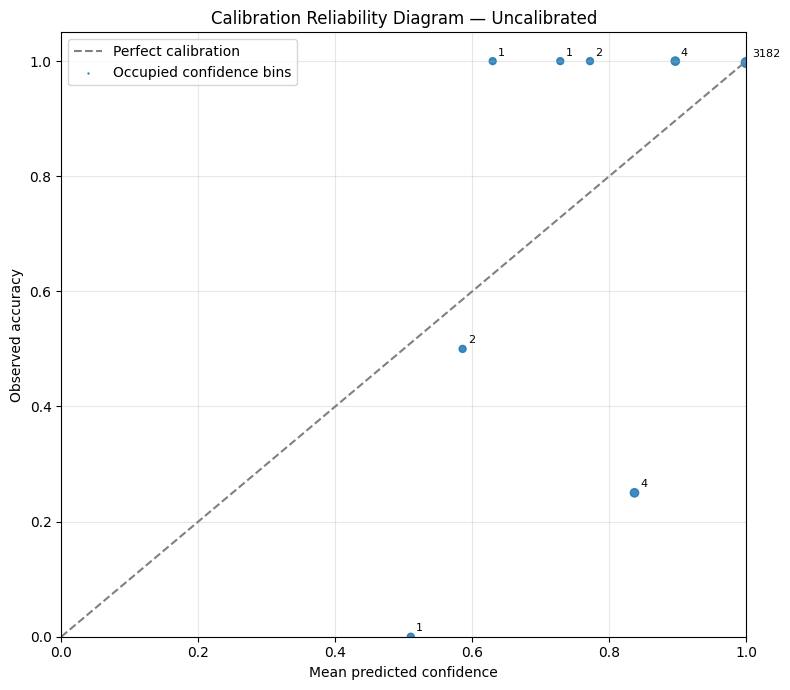

Saved: /kaggle/working/main19_test_evaluation_outputs/figures/fig_03_calibration_reliability_uncalibrated.png


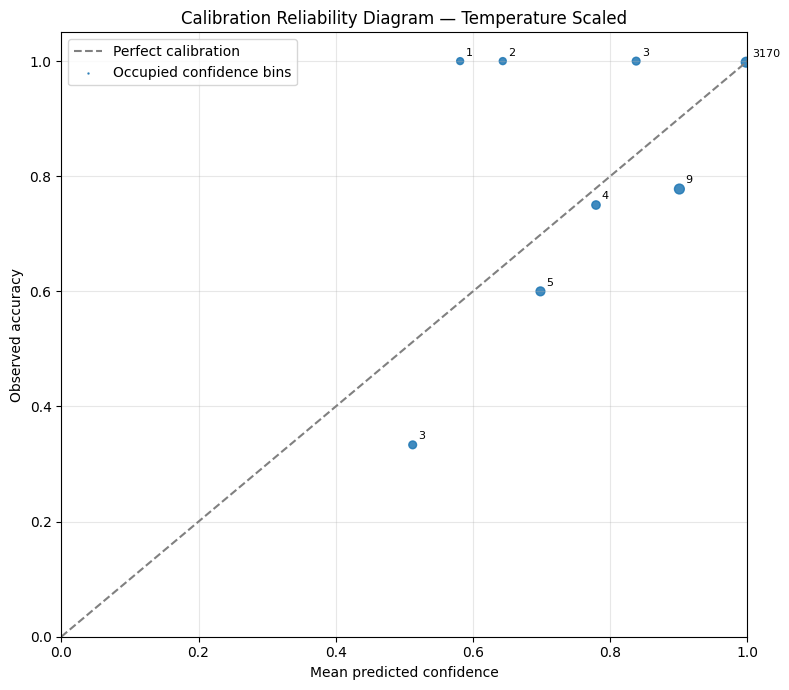

Saved: /kaggle/working/main19_test_evaluation_outputs/figures/fig_04_calibration_reliability_temperature_scaled.png


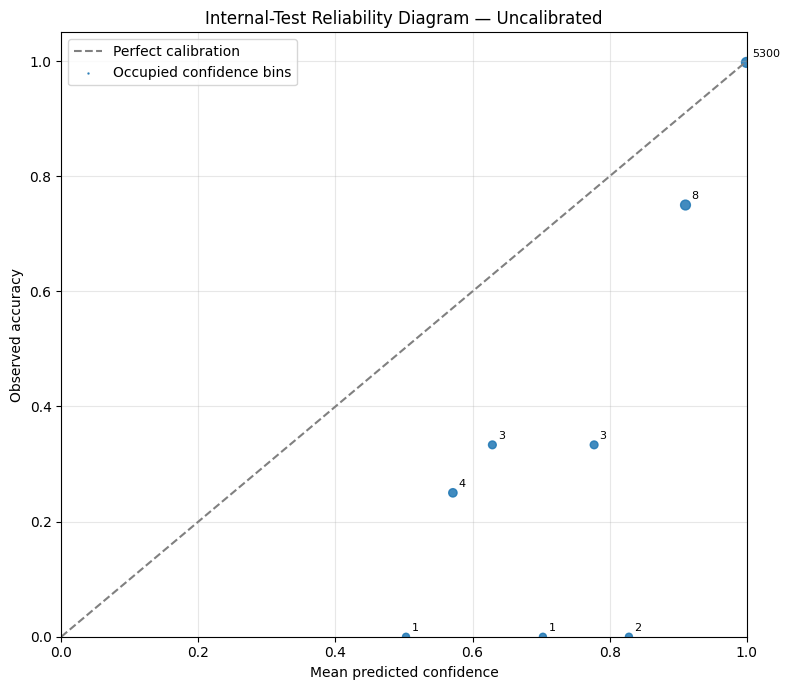

Saved: /kaggle/working/main19_test_evaluation_outputs/figures/fig_05_test_reliability_uncalibrated.png


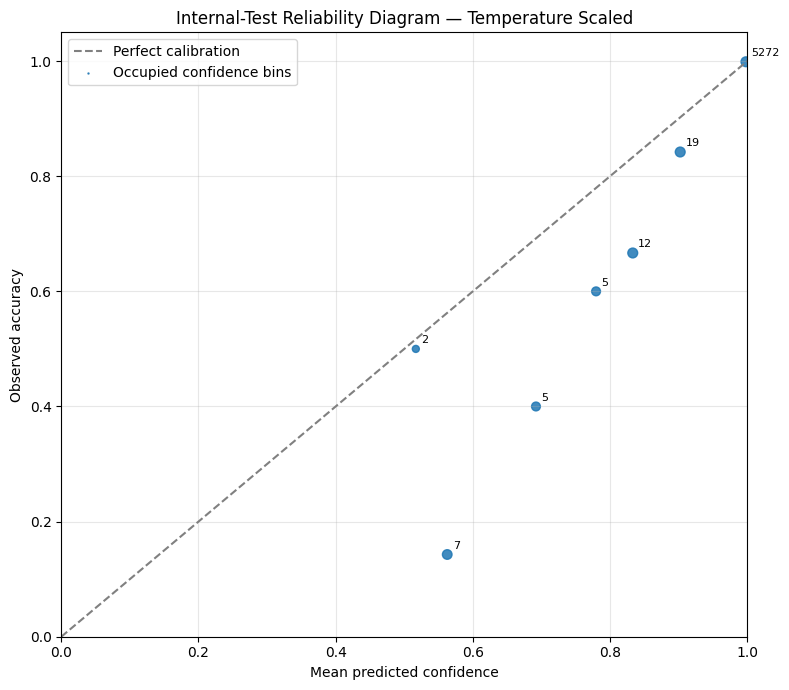

Saved: /kaggle/working/main19_test_evaluation_outputs/figures/fig_06_test_reliability_temperature_scaled.png


In [19]:
def plot_reliability_diagram(probs, targets, n_bins, title, output_path):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    correct = (predictions == targets).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    occupied_confidences = []
    occupied_accuracies = []
    occupied_counts = []

    for start, end in zip(bin_edges[:-1], bin_edges[1:]):
        if start == 0.0:
            in_bin = (confidences >= start) & (confidences <= end)
        else:
            in_bin = (confidences > start) & (confidences <= end)

        count = int(in_bin.sum())

        if count > 0:
            occupied_confidences.append(confidences[in_bin].mean())
            occupied_accuracies.append(correct[in_bin].mean())
            occupied_counts.append(count)

    plt.figure(figsize=(8, 7))

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Perfect calibration"
    )

    plt.scatter(
        occupied_confidences,
        occupied_accuracies,
        s=np.clip(np.sqrt(np.array(occupied_counts)) * 18,25,50),
        color="#1f77b4",
        alpha=0.85,
        label="Occupied confidence bins"
    )

    for confidence, accuracy, count in zip(
        occupied_confidences,
        occupied_accuracies,
        occupied_counts
    ):
        plt.annotate(
            str(count),
            (confidence, accuracy),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8
        )

    plt.xlabel("Mean predicted confidence")
    plt.ylabel("Observed accuracy")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.grid(alpha=0.3)
    legend = plt.legend(loc="upper left",markerscale=0.12,scatterpoints=1)
    plt.tight_layout()

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", output_path)

N_BINS = 15

# Calibration set diagrams
plot_reliability_diagram(
    calib_uncal_probs,
    calib_targets.numpy(),
    n_bins=N_BINS,
    title="Calibration Reliability Diagram — Uncalibrated",
    output_path=FIG_DIR / "fig_03_calibration_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    calib_cal_probs,
    calib_targets.numpy(),
    n_bins=N_BINS,
    title="Calibration Reliability Diagram — Temperature Scaled",
    output_path=FIG_DIR / "fig_04_calibration_reliability_temperature_scaled.png"
)

# Test set diagrams
plot_reliability_diagram(
    test_uncal_probs,
    test_targets.numpy(),
    n_bins=N_BINS,
    title="Internal-Test Reliability Diagram — Uncalibrated",
    output_path=FIG_DIR / "fig_05_test_reliability_uncalibrated.png"
)

plot_reliability_diagram(
    test_cal_probs,
    test_targets.numpy(),
    n_bins=N_BINS,
    title="Internal-Test Reliability Diagram — Temperature Scaled",
    output_path=FIG_DIR / "fig_06_test_reliability_temperature_scaled.png"
)

In [20]:
run_metadata = {
    "notebook": "04_temperature_scaling_and_internal_test_evaluation",
    "completed_utc": datetime.now(timezone.utc).isoformat(),
    "temperature": float(temperature_scaler.temperature),
    "calibration_uncalibrated": calib_uncal_metrics,
    "calibration_temperature_scaled": calib_cal_metrics,
    "test_uncalibrated": test_uncal_metrics,
    "test_temperature_scaled": test_cal_metrics,
    "checkpoint_path": str(BEST_CHECKPOINT_PATH),
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

run_metadata_path = METADATA_DIR / "test_evaluation_run_metadata.json"
with open(run_metadata_path, "w") as file:
    json.dump(run_metadata, file, indent=2)

print(json.dumps(run_metadata, indent=2))

print("\nNOTEBOOK 04 COMPLETED")
print("=" * 72)

print("\nMain19 internal-test results")
print("Uncalibrated macro-F1:",
      round(test_uncal_metrics["macro_f1"], 5))
print("Temperature-scaled macro-F1:",
      round(test_cal_metrics["macro_f1"], 5))

print("\nKey outputs directory:")
print(OUTPUT_DIR)

{
  "notebook": "04_temperature_scaling_and_internal_test_evaluation",
  "completed_utc": "2026-08-13T11:58:33.913066+00:00",
  "temperature": 1.5694622993469238,
  "calibration_uncalibrated": {
    "split": "calibration_uncalibrated",
    "accuracy": 0.9959336878323428,
    "balanced_accuracy": 0.9938555023928038,
    "macro_f1": 0.9939520934929097,
    "nll": 0.018499738463369313,
    "brier": 0.006991914259789932,
    "ece": 0.003922897687284965
  },
  "calibration_temperature_scaled": {
    "split": "calibration_temperature_scaled",
    "accuracy": 0.9959336878323428,
    "balanced_accuracy": 0.9938555023928038,
    "macro_f1": 0.9939520934929097,
    "nll": 0.018299590958497376,
    "brier": 0.006775204976835298,
    "ece": 0.0012968502493623678
  },
  "test_uncalibrated": {
    "split": "test_uncalibrated",
    "accuracy": 0.9953025178504322,
    "balanced_accuracy": 0.99320449550139,
    "macro_f1": 0.9929314817092859,
    "nll": 0.015500791849396449,
    "brier": 0.007042107194